In [2]:
#Import libraries
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

In [4]:
#Load MNIST dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
x = mnist.data
y = mnist.target.astype(int)
print("Dataset shape:", x.shape)

Dataset shape: (70000, 784)


In [5]:
#split the dataset into training and testing
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [6]:
#Standardization
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [7]:
#Simple Perceptron
perceptron=Perceptron(max_iter=100,random_state=42)
#Model training
perceptron.fit(x_train,y_train)

#Perdiction
y_pred_perceptron=perceptron.predict(x_test)

#Evaluation
accuracy_perceptron=accuracy_score(y_test,y_pred_perceptron)
print("Perceptron Accuracy:",accuracy_perceptron)


Perceptron Accuracy: 0.881


In [8]:
#Multi-Layer Perceptron
mlp=MLPClassifier(hidden_layer_sizes=(128,64),max_iter=100,random_state=42)

#Model training
mlp.fit(x_train,y_train)

#prediction
y_pred_mlp=mlp.predict(x_test)

#Evaluation
accuracy_mlp=accuracy_score(y_test,y_pred_mlp)
print("Multi-Layer Perceptron Accuracy:",accuracy_mlp)

Multi-Layer Perceptron Accuracy: 0.976


In [10]:
# 7. Comparison
print("\nPerformance Comparison")
print("Perceptron Accuracy : {:.2f}%".format(accuracy_perceptron * 100))
print("MLP Accuracy : {:.2f}%".format(accuracy_mlp * 100))


Performance Comparison
Perceptron Accuracy : 88.10%
MLP Accuracy : 97.60%


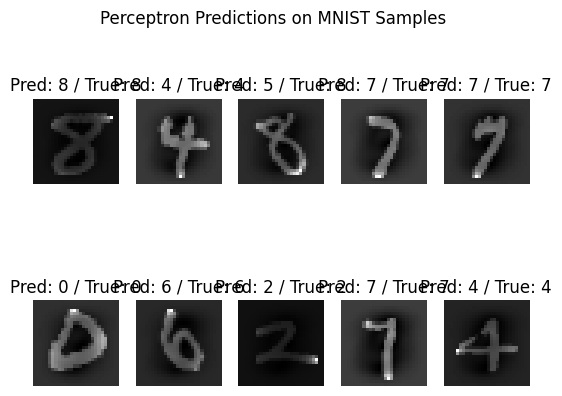

In [12]:
import matplotlib.pyplot as plt

#8.Visualization
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(x_test[i].reshape(28,28),cmap='gray')
  plt.title(f"Pred: {y_pred_perceptron[i]} / True: {y_test[i]}")
  plt.axis('off')
  plt.suptitle("Perceptron Predictions on MNIST Samples")
plt.show()